<a href="https://colab.research.google.com/github/s326327/Days-1---5-Data-Science/blob/main/Lesson2_Three_Ways_to_Describe_Typical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Lesson2: Three Ways to Describe Typical.ipynb', 'Data', 'Lesson1: Data is Messy.ipynb']
['climate_austin.csv']
(31047, 2)
['date', 'temp_max']
         date  temp_max
0  1940-01-01      12.2
1  1940-01-02       8.7
2  1940-01-03      14.8
3  1940-01-04      12.6
4  1940-01-05      10.5
   temp_max  temp_max_f
0      12.2       53.96
1       8.7       47.66
2      14.8       58.64
3      12.6       54.68
4      10.5       50.90
object
datetime64[ns]
        date  year
0 1940-01-01  1940
1 1940-01-02  1940
2 1940-01-03  1940
3 1940-01-04  1940
4 1940-01-05  1940
year
1940    74.860164
1941    73.588384
1942    74.747781
1943    77.564658
1944    77.513934
1945    78.490301
1946    75.630521
1947    75.695616
1948    78.484754
1949    77.807288
Name: temp_max_f, dtype: float64
(85,)
Mean annual temperature: 77.9 F
Median annual temperature: 77.9 F
count    310

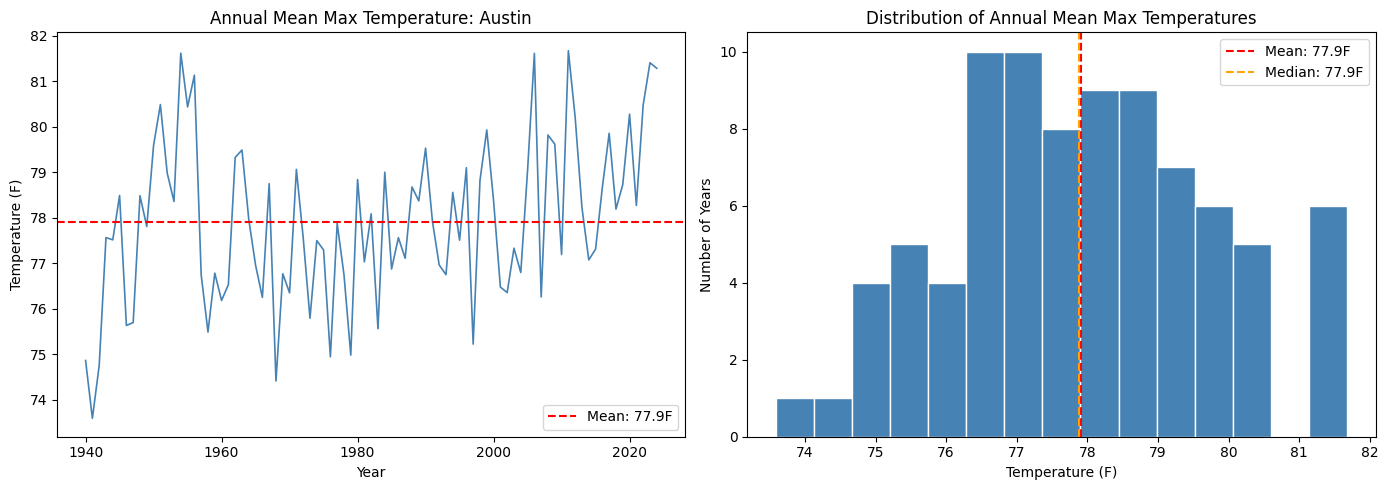

    year  month  temp_max_f
0   1940      1   51.660645
1   1940      2   60.787586
2   1940      3   70.943871
3   1940      4   75.086000
4   1940      5   78.753548
5   1940      6   82.766000
6   1940      7   86.975484
7   1940      8   92.265161
8   1940      9   89.966000
9   1940     10   82.527742
10  1940     11   64.898000
11  1940     12   61.212258
12  1941      1   61.206452
13  1941      2   59.739286
14  1941      3   61.090323
(85, 2)
   year  mean_temp_max_f
0  1940        74.860164
1  1941        73.588384
2  1942        74.747781
3  1943        77.564658
4  1944        77.513934


In [ ]:
from google.colab import drive

drive.mount('/content/drive')
import os

folder = '/content/drive/MyDrive/Data Science/'
print(os.listdir(folder))
print(os.listdir('/content/drive/MyDrive/Data Science/Data/'))
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())
df['temp_max_f'] = df['temp_max'] * 9/5 + 32
print(df[['temp_max', 'temp_max_f']].head())
print(df['date'].dtype)
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)
df['year'] = df['date'].dt.year
print(df[['date', 'year']].head())
annual = df.groupby('year')['temp_max_f'].mean()
print(annual.head(10))
print(annual.shape)
overall_mean = annual.mean()
print(f'Mean annual temperature: {overall_mean:.1f} F')
overall_median = annual.median()
print(f'Median annual temperature: {overall_median:.1f} F')
print(df['temp_max_f'].describe())
print(overall_mean)
print(overall_median)
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Line plot over time
ax1.plot(annual.index, annual.values, color='steelblue', linewidth=1.2)
ax1.axhline(overall_mean, color='red', linestyle='--', label=f'Mean: {overall_mean:.1f}F')
ax1.set_title('Annual Mean Max Temperature: Austin')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature (F)')
ax1.legend()

# Histogram of annual means
ax2.hist(annual.values, bins=15, color='steelblue', edgecolor='white')
ax2.axvline(overall_mean, color='red', linestyle='--', label=f'Mean: {overall_mean:.1f}F')
ax2.axvline(overall_median, color='orange', linestyle='--', label=f'Median: {overall_median:.1f}F')
ax2.set_title('Distribution of Annual Mean Max Temperatures')
ax2.set_xlabel('Temperature (F)')
ax2.set_ylabel('Number of Years')
ax2.legend()

plt.tight_layout()
plt.show()
monthly = df.groupby([df['date'].dt.year, df['date'].dt.month])['temp_max_f'].mean()
monthly.index.names = ['year', 'month']
monthly_df = monthly.reset_index()
print(monthly_df.head(15))
annual_df = annual.reset_index()
annual_df.columns = ['year', 'mean_temp_max_f']
annual_df.to_csv('annual_summary_austin.csv', index=False)
print(annual_df.shape)
print(annual_df.head())